In [1]:
import os
os.chdir('./stat_csv')
os.getcwd()

'/home/tako/Kasetsart/statistics/stat_csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
from sklearn.model_selection import train_test_split

### Load Dataset

In [4]:
orig_df = pd.read_csv("bank_edited.csv")
orig_df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,unknown,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,unknown,14,may,57,2,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


In [5]:
orig_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [6]:
orig_df['y'] = orig_df['y'].map({'yes': 1, 'no': 0})
orig_df['y'].value_counts()

y
0    4000
1     521
Name: count, dtype: int64

In [7]:
orig_y = orig_df['y']
orig_y

0       0
1       0
2       0
3       0
4       0
       ..
4516    0
4517    0
4518    0
4519    0
4520    0
Name: y, Length: 4521, dtype: int64

In [8]:
df = orig_df.copy()

In [9]:
orig_X = df.drop(['y'], axis=1)
orig_X.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome'],
      dtype='object')

In [10]:
orig_X.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
dtype: object

In [11]:
# Finding categorical variables
cat_features = orig_X.select_dtypes(include=["object", "category"]).columns
cat_features

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

In [12]:
# Finding numerical variables
num_features = orig_X.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_features

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [13]:
num_orig_X = df[num_features]
num_orig_X.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

### Scaling

In [14]:
# Scale by standardized normal distribution, (x-mean)/sd
def scale_standard(X_train, X_test):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by min-max, (x-min)/(max-min)
def scale_minmax(X_train, X_test):
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Scale by robust, (x-median)/iqr
def scale_minmax(X_train, X_test):
    from sklearn.preprocessing import RobustScaler
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

### Encoding Categorical Data

In [15]:
# One-Hot Encoder version 1: convert all categorical variables
def onehot_encoder_all(df):
    from sklearn.preprocessing import OneHotEncoder
    onehot_encoder = OneHotEncoder(sparse_output=False,        # use sparse=True for large data
                                    handle_unknown='ignore')
    oh_encoded = onehot_encoder.fit_transform(df)
    ohe_df = pd.DataFrame(oh_encoded,
                         columns=onehot_encoder.get_feature_names_out(df.columns))
    return ohe_df

# One-Hot Encoder version 2: Convert selected variables
def onehot_encoder_selected(df, encoded_vars):
    df = pd.get_dummies(df, columns=encoded_vars, drop_first=False)
    return df

# Label Encoder
def label_encoder(df, encoded_var):
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    df[encoded_var] = label_encoder.fit_transform(df[encoded_var])
    return df

# Ordinal Encoder
def ordinal_encoder(df, encoded_var, encode_order):
    from sklearn.preprocessing import OrdinalEncoder
    ordinal_encoder = OrdinalEncoder(categories=[encode_order])
    df[encoded_var] = ordinal_encoder.fit_transform(df[[encoded_var]])
    return df

In [16]:
# Frequenct Encoder
def frequent_encoder(df, encoded_var):
    freq_encoding = df[encoded_var].value_counts() 
    df[encoded_var] = df[encoded_var].map(freq_encoding)
    return df

# Target Encoder
def target_encoder(df, encoded_var, encoded_num):
    import category_encoders as ce
    target_encoder = ce.TargetEncoder(cols=[encoded_var])
    df[encoded_var] = target_encoder.fit_transform(df[encoded_var], df[encoded_num])
    return df

# Binary Encoder
def binary_encoder(df, encoded_var):
    import category_encoders as ce
    binary_encoder = ce.BinaryEncoder(cols=[encoded_var])
    df_binary = binary_encoder.fit_transform(df[encoded_var])
    df_binary.columns = [f"{encoded_var}_bin_{i}" for i in range(df_binary.shape[1])]
    df = pd.concat([df, df_binary], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

### Hash Encoder
def hash_encoder(df, encoded_var, hash_len):
    import category_encoders as ce
    hash_encoder = ce.HashingEncoder(cols=[encoded_var], n_components=hash_len)  # n_components = length of hash, default = 8
    df_hash = hash_encoder.fit_transform(df[encoded_var])
    df_hash.columns = [f"{encoded_var}_hash_{i}" for i in range(df_hash.shape[1])]
    df = pd.concat([df, df_hash], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

### Handling Imbalance

In [17]:
# Undersampling
def undersampling(X,y):
    from imblearn.under_sampling import RandomUnderSampler
    X_res, y_res = RandomUnderSampler().fit_resample(X, y)
    return X_res, y_res

# Oversampling
def oversampling(X,y):
    from imblearn.over_sampling import RandomOverSampler
    X_res, y_res = RandomOverSampler().fit_resample(X, y)
    return X_res, y_res

# SMOTE
def smote(X,y):
    from imblearn.over_sampling import SMOTE
    X_res, y_res = SMOTE().fit_resample(X, y)
    return X_res, y_res

### Performance Evaluation

In [18]:
# Function to compute performance classification metrics
def evaluate_performance(y_true, y_pred, average_val='macro'):

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=average_val)
    recall = recall_score(y_true, y_pred, average=average_val)
    f1 = f1_score(y_true, y_pred, average=average_val)

    from sklearn.metrics import confusion_matrix
    confusion = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, f1, confusion

In [19]:
def plot_roc_auc(y_true, y_pred):
    from sklearn.metrics import roc_curve, roc_auc_score
    import matplotlib.pyplot as plt

    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)

    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (AUC = {auc:.3f})")
    plt.show()

    return auc

### Check Feature Importance

In [20]:
def get_permutation_importance(model, X, X_true, y_true):
    from sklearn.inspection import permutation_importance
    result = permutation_importance(model, X_test, y_test, n_repeats=10)
    
    perm_df = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False)
    
    return perm_df

    # Higher value = more important feature, relatively compared to other features
    # Near-zero value = unimportant feature, relatively compared to other features
    # Negative value = noisy feature

In [21]:
def create_shap_values_plot(model, X, X_train, X_test):
    import shap
    X_train_df = pd.DataFrame(X_train, columns=X.columns.tolist())
    X_test_df = pd.DataFrame(X_test, columns=X.columns.tolist())
    if len(X_train) > 200:
        explainer = shap.KernelExplainer(model.predict, X_train_df.sample(200))
    else: 
        explainer = shap.KernelExplainer(model.predict, X_train_df)
    if len(X_test) > 100:
        shap_values = explainer.shap_values(X_test_df.sample(100))
        shap.summary_plot(shap_values, X_test_df.sample(100))
    else:
        shap_values = explainer.shap_values(X_test_df)
        shap.summary_plot(shap_values, X_test_df)

### Experiments: Interpretability

In [22]:
print('job: ',orig_X['job'].unique())
print('marital: ',orig_X['marital'].unique())
print('education: ',orig_X['education'].unique())
print('default: ',orig_X['default'].unique())
print('housing: ',orig_X['housing'].unique())
print('loan: ',orig_X['loan'].unique())
print('contact: ',orig_X['contact'].unique())
print('month: ',orig_X['month'].unique())
print('poutcome: ',orig_X['poutcome'].unique())

job:  ['unemployed' 'services' 'management' 'blue-collar' 'self-employed'
 'technician' 'entrepreneur' 'admin.' 'student' 'housemaid' 'retired'
 'unknown']
marital:  ['married' 'single' 'divorced']
education:  ['primary' 'secondary' 'tertiary' 'unknown']
default:  ['no' 'yes']
housing:  ['no' 'yes']
loan:  ['no' 'yes']
contact:  ['cellular' 'unknown' 'telephone']
month:  ['oct' 'may' 'apr' 'jun' 'feb' 'aug' 'jan' 'jul' 'nov' 'sep' 'mar' 'dec']
poutcome:  ['unknown' 'failure' 'other' 'success']


In [23]:
# Data preprocessing 

X = orig_X.copy()
y = orig_y.copy()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

############## Categorical Data Encoding ##############
## Nominal -> binary classes -> Binay mapping
X_train['default'] = X_train['default'].map({'yes': 1, 'no': 0})
X_test['default'] = X_test['default'].map({'yes': 1, 'no': 0})
X_train['housing'] = X_train['housing'].map({'yes': 1, 'no': 0})
X_test['housing'] = X_test['housing'].map({'yes': 1, 'no': 0})
X_train['loan'] = X_train['loan'].map({'yes': 1, 'no': 0})
X_test['loan'] = X_test['loan'].map({'yes': 1, 'no': 0})
#######################################################
## Nominal -> one hot 
encoded_vars = ['job', 'marital','contact','poutcome']
X_train = onehot_encoder_selected(X_train, encoded_vars)
X_test = onehot_encoder_selected(X_test, encoded_vars)
#######################################################
## Ordinal -> Label Encoder
encoded_var = 'education'
encode_order = ['unknown', 'primary', 'secondary', 'tertiary']  # Item1 = 0, Item2= 1, ... 
X_train = ordinal_encoder(X_train, encoded_var, encode_order)
X_test = ordinal_encoder(X_test, encoded_var, encode_order)

encoded_var = 'month'
encode_order = ['','jan', 'feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
X_train = ordinal_encoder(X_train, encoded_var, encode_order)
X_test = ordinal_encoder(X_test, encoded_var, encode_order)
#######################################################

############## Imbalance Handling here ##############
# Smote Example
X_train, y_train = smote(X_train,y_train)
print(X_train.shape, y_train.shape)
y_train.value_counts()
#######################################################

base_X_train = X_train.copy()
base_X_test = X_test.copy()

base_X_train.head()

(6386, 34) (6386,)


,age,education,default,balance,housing,loan,day,month,duration,campaign,...,marital_divorced,marital_married,marital_single,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,34,3.0,0,262,0,0,20,11.0,371,1,...,True,False,False,True,False,False,False,False,False,True
1,32,3.0,0,2349,0,0,14,8.0,134,5,...,False,True,False,True,False,False,False,False,False,True
2,34,2.0,0,1076,0,0,8,8.0,70,2,...,False,False,True,True,False,False,False,False,False,True
3,31,3.0,0,156,0,0,13,8.0,657,7,...,False,True,False,True,False,False,False,False,False,True
4,46,1.0,0,258,1,0,27,5.0,217,1,...,False,True,False,False,False,True,False,False,False,True


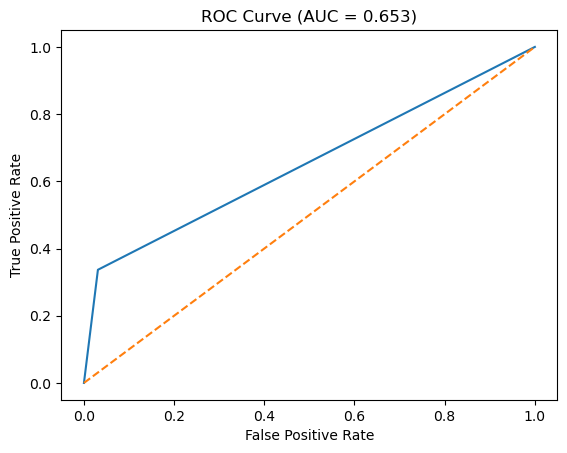

0.652877879776446
[[782  25]
 [ 65  33]]
0.9005524861878453 0.7461120384317876 0.6528778797764458 0.6843316900753418


In [24]:
# Model Construction & Performance Evaluation

X_train = base_X_train.copy()
X_test = base_X_test.copy()

# Scaling 
X_train, X_test = scale_standard(X_train, X_test)

#######################################################
# Construct a model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
#######################################################

# Use model for predicted responses
y_pred = model.predict(X_test)

# Measure performances
auc = plot_roc_auc(y_test, y_pred)
print(auc)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

In [25]:
# Find out the importance features: Permuation Importance
get_permutation_importance(model, base_X_train, X_test, y_test)

,feature,importance_mean,importance_std
27,contact_cellular,0.162541,0.008846
25,marital_married,0.142541,0.008014
16,job_management,0.133149,0.007165
26,marital_single,0.128398,0.010004
29,contact_unknown,0.128398,0.011234
13,job_blue-collar,0.119006,0.006329
21,job_technician,0.104199,0.006073
12,job_admin.,0.084641,0.005350
19,job_services,0.068066,0.005975
24,marital_divorced,0.065083,0.005310


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/100 [00:00<?, ?it/s]

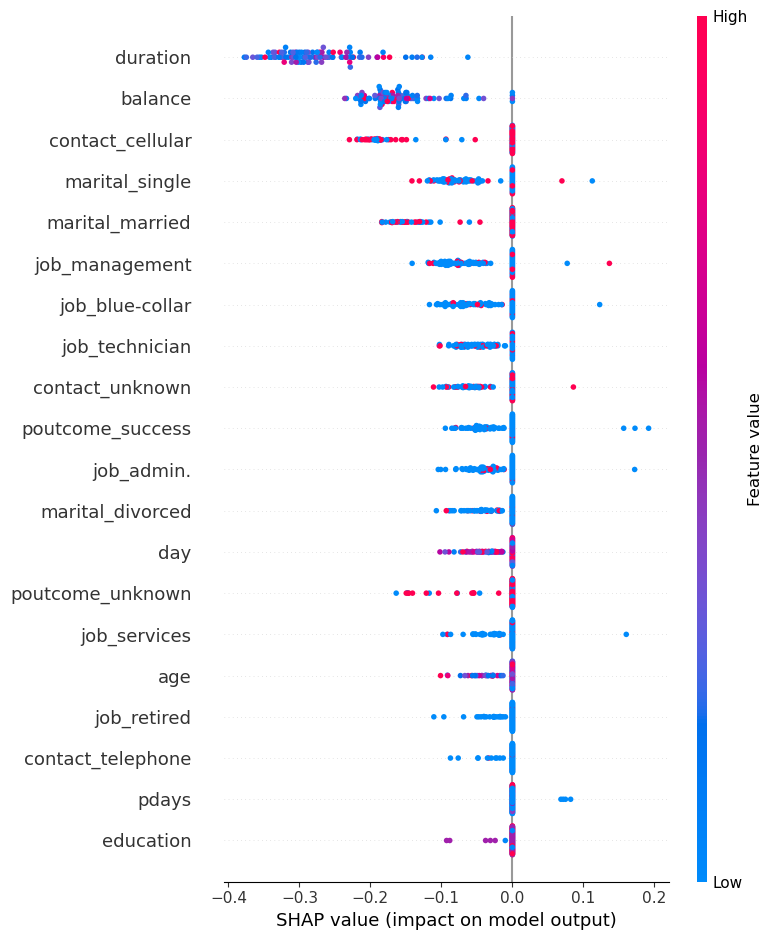

In [26]:
# Find out the importance features: SHAP values
create_shap_values_plot(model, base_X_train, base_X_train, X_test)

### Analaysis of Categorical Data

#### Independence Test

In [27]:
# Prove: Are job and y (subscribed or not) independent?
# H0: X and Y are independent 
# H1: X and Y are not independent
# Decision: if p < 0.05 → Reject H0 -> X and Y are not independent -> They are association

In [28]:
contingency_table = pd.crosstab(df['job'], df['y'])
print(contingency_table)

y                0    1
job                    
admin.         420   58
blue-collar    877   69
entrepreneur   153   15
housemaid       98   14
management     838  131
retired        176   54
self-employed  163   20
services       379   38
student         65   19
technician     685   83
unemployed     115   13
unknown         31    7


In [29]:
# Chi-square test
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 68.98828575267176
p-value: 1.901391096662705e-10


In [30]:
# Question: Are job and y (subscribed or not) independent?
# Answer and provide the reason: X and Y are not independent since p = 1.901391096662705e-10 < 0.05 -> Reject H0

#### Homogeneity Test

In [31]:
# Prove: Do different marital groups have the same distribution of subscription (y)?
# H0: P1j = P2j = ... Pkj  (Distributions of category j among groups 1, 2, ..., k are the same.)
# H1: At least one group does not have the same distribution
# Decision: If p < 0.05 → Reject H0 → Distributions differ

In [32]:
# Contingency table (rows = groups, columns = categories)
contingency_table = pd.crosstab(df['marital'], df['y'])
print(contingency_table)

y            0    1
marital            
divorced   451   77
married   2520  277
single    1029  167


In [33]:
# Chi-square test
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 19.03005634409817
p-value: 7.373535401823763e-05


In [34]:
# Question: Do different marital groups have the same distribution of subscription (y)?
# Answer and provide the reason: At least one group does not have the same distribution because p = 7.373535401823763e-05 < 0.05 -> Reject H0

### Analysis of Variance: Single Factor

In [35]:
# Prove: Does the mean of balance differ among different job categories?
# H0: m1 = m2 = ... = mJ (means of each cateogory are the same.)
# H1: At least one pair is not the same
# Decision: if p < alpha (significant level) → Reject H0 → (C(job)) job affects balance

In [36]:
# Check categorical variable
df['job'] = df['job'].astype('category')

# Group numeric variable (balance) by categorical factor (job)
groups = [df[df['job'] == j]['balance'] for j in df['job'].unique()]

In [37]:
# Perform Anova test
from statsmodels.formula.api import ols
model = ols('balance ~ C(job)', data=df).fit()

import statsmodels.api as sm
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                sum_sq      df        F        PR(>F)
C(job)    5.477477e+08    11.0  5.55841  6.605018e-09
Residual  4.039406e+10  4509.0      NaN           NaN


In [38]:
# Question: Does the mean of balance differ among different job categories?
# Answer and provide the reason: the mean of balance differs since p = 6.605018e-09 < alpha in PR(>F) = 0.05 -> Rejects H0

### Analysis of Variance: Two Factors

In [39]:
# Prove: Does the mean of balance differ by job (A) and marital status (B), and is there an interaction between them (A and B)?
# IF p < alpha (significant level) → Reject H0 → statistically significant effect
# Reject H0AB: C(job):C(marital) → Interaction affects balance
# Reject H0A: C(job) → Job affects balance
# Reject H0B: C(marital) → marital affects balance

In [40]:
# Check categorical types
df['job'] = df['job'].astype('category')
df['marital'] = df['marital'].astype('category')

In [41]:
# Perform Anova test
from statsmodels.formula.api import ols
# Two-way ANOVA with interaction
model = ols(
    'balance ~ C(job) + C(marital) + C(job):C(marital)',
    data=df
).fit()

import statsmodels.api as sm
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                         sum_sq      df         F        PR(>F)
C(job)             6.116695e+08    11.0  6.222595  1.613527e-09
C(marital)         6.940501e+07     2.0  3.883365  2.065068e-02
C(job):C(marital)  2.440688e+08    22.0  1.241472  2.004104e-01
Residual           4.008777e+10  4486.0       NaN           NaN


/nix/store/vjsppi2xr3cqx01dgwqzdy4baxysqzfk-devenv-profile/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 10
  warnings.warn('covariance of constraints does not have full '


In [42]:
# Question: Is there an interaction between job (A) and marital status (B)?
# Answer and provide the reason: No interaction between job (A) and marital status (B) since the p = 2.004104e-01 > alpha = 0.05 -> H0AB is satisfied

In [43]:
# Question: Does the mean of balance differ by job (A)?
# Answer and provide the reason: Job do affects the mean of balance which p = 2.065068e-02 < alpha = 0.05 -> Reject H0A

In [44]:
# Question: Does the mean of balance differ by marital status (B)?
# Answer and provide the reason: Marital do affects the mean of balance which p = 1.613527e-09 < alpha = 0.05 -> Reject H0B